# 🔧 Bearing Remaining Useful Life (RUL) Prediction

## Complete Analysis & Visualization Notebook

This notebook demonstrates the full pipeline used in the **Bearing RUL Prediction** application:

1. **Data Generation / Loading** — Synthetic (demo) or real XJTU-SY bearing dataset
2. **Exploratory Data Analysis (EDA)** — Feature distributions, correlations, degradation patterns
3. **Model Training** — XGBoost Gradient Boosted Trees with hyperparameter tuning
4. **Model Evaluation** — R², RMSE, MAE, residual analysis, per-bearing breakdown
5. **Visualizations** — Comprehensive plots for understanding model performance

---

## 1. Setup & Imports

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Add project path for local imports
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from app.data_preprocessing import generate_synthetic_dataset, build_feature_matrix
from app.feature_extraction import FEATURE_NAMES
from app.model import get_training_features

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})

# Color palette
COLORS = {
    'primary': '#6366f1',
    'secondary': '#8b5cf6',
    'success': '#10b981',
    'warning': '#f59e0b',
    'danger': '#ef4444',
    'info': '#3b82f6',
    'dark': '#1e293b',
}
CMAP = plt.cm.viridis

print("✅ All imports successful!")

✅ All imports successful!


## 2. Data Loading

Choose one of two modes:
- **Demo mode** (default): Generate synthetic data mimicking XJTU-SY patterns
- **Real data**: Point to the XJTU-SY Bearing Dataset directory

Set `USE_REAL_DATA = True` and update `DATA_DIR` if you have the real dataset.

In [8]:
# ========================================
#  Configuration — edit these as needed
# ========================================
USE_REAL_DATA = False  # Set True if you have the XJTU-SY dataset
DATA_DIR = r"path/to/XJTU-SY-Bearing-Datasets"  # Only used when USE_REAL_DATA=True

N_BEARINGS = 8           # Number of synthetic bearings (demo mode)
SAMPLES_PER_BEARING = 300  # Samples per bearing (demo mode)
TEST_SIZE = 0.2          # Fraction held out for testing
RANDOM_STATE = 42

# ========================================
#  Load or generate data
# ========================================
if USE_REAL_DATA:
    print(f"📂 Loading real XJTU-SY data from: {DATA_DIR}")
    df = build_feature_matrix(DATA_DIR)
else:
    print("🧪 Generating synthetic demo dataset...")
    df = generate_synthetic_dataset(n_bearings=N_BEARINGS, samples_per_bearing=SAMPLES_PER_BEARING)

print(f"\n📊 Dataset shape: {df.shape}")
print(f"   Bearings:           {df['bearing_name'].nunique()}")
print(f"   Total samples:      {len(df)}")
print(f"   Features:           {len(FEATURE_NAMES)} vibration + 2 metadata = {len(FEATURE_NAMES)+2}")
print(f"   RUL range:          {df['rul'].min():.1f} – {df['rul'].max():.1f} minutes")
print(f"   Operating conds:    {sorted(df['operating_condition'].unique())}")

🧪 Generating synthetic demo dataset...

📊 Dataset shape: (2400, 32)
   Bearings:           8
   Total samples:      2400
   Features:           28 vibration + 2 metadata = 30
   RUL range:          0.0 – 125.0 minutes
   Operating conds:    [1, 2, 3]


In [9]:
# Export the dataset to CSV for reference
csv_path = 'bearing_features_dataset.csv'
df.to_csv(csv_path, index=False)
print(f"💾 Dataset saved to: {os.path.abspath(csv_path)}")
print(f"   File size: {os.path.getsize(csv_path) / 1024:.1f} KB")

💾 Dataset saved to: d:\coding\RUL bearing\backend\bearing_features_dataset.csv
   File size: 1331.1 KB


In [10]:
# Quick peek at the data
df.head(10)

,h_rms,h_peak,h_peak_to_peak,h_crest_factor,h_kurtosis,h_skewness,h_std_dev,h_shape_factor,h_impulse_factor,h_margin_factor,...,v_impulse_factor,v_margin_factor,v_freq_center,v_mean_sq_freq,v_rms_freq,v_freq_variance,rul,bearing_name,operating_condition,normalized_time
0,0.059569,0.178209,0.355921,3.004967,3.024836,0.004967,0.059320,1.250993,5.191370,7.377773,...,5.164856,7.338002,2991.710050,1.491710e+07,3787.565075,4.958550e+06,125.0,Synthetic_1_1,1,0.000000
1,0.059025,0.177766,0.355394,3.000290,2.993087,0.000290,0.059094,1.250058,5.180500,7.362383,...,5.172062,7.349726,2996.070430,1.496070e+07,3793.603973,4.982024e+06,125.0,Synthetic_1_1,1,0.003344
2,0.059903,0.179062,0.357477,3.009821,3.032386,0.009821,0.059580,1.251964,5.198067,7.389658,...,5.200059,7.392646,3010.817418,1.510817e+07,3815.222782,5.057432e+06,125.0,Synthetic_1_1,1,0.006689
3,0.060872,0.181093,0.360663,3.020247,3.076157,0.020247,0.060111,1.254049,5.217441,7.419651,...,5.199188,7.392272,3011.120425,1.511120e+07,3815.175621,5.060619e+06,125.0,Synthetic_1_1,1,0.010033
4,0.059209,0.178798,0.357362,3.004347,2.988304,0.004347,0.059326,1.250869,5.184183,7.370707,...,5.188448,7.377104,3006.479947,1.506480e+07,3807.713232,5.039089e+06,125.0,Synthetic_1_1,1,0.013378
5,0.059304,0.179084,0.357933,3.006020,2.988317,0.006020,0.059421,1.251204,5.186087,7.374516,...,5.193117,7.385060,3009.534478,1.509534e+07,3811.793356,5.056034e+06,125.0,Synthetic_1_1,1,0.016722
6,0.061214,0.182063,0.362546,3.025826,3.079001,0.025826,0.060424,1.255165,5.224278,7.432764,...,5.218247,7.423718,3022.810094,1.522810e+07,3831.205107,5.124084e+06,125.0,Synthetic_1_1,1,0.020067
7,0.060499,0.180730,0.360693,3.019380,3.038436,0.019380,0.060116,1.253876,5.209986,7.412297,...,5.182806,7.371527,3005.789972,1.505790e+07,3805.173252,5.040656e+06,125.0,Synthetic_1_1,1,0.023411
8,0.059361,0.180429,0.360388,3.008683,2.976622,0.008683,0.059595,1.251737,5.187210,7.379115,...,5.207542,7.409612,3018.848900,1.518849e+07,3824.259972,5.107622e+06,125.0,Synthetic_1_1,1,0.026756
9,0.060472,0.180872,0.361202,3.020476,3.027264,0.020476,0.060200,1.254095,5.209433,7.413441,...,5.194538,7.391099,3013.028241,1.513028e+07,3815.027311,5.080191e+06,125.0,Synthetic_1_1,1,0.030100


In [11]:
df.describe().T.style.background_gradient(cmap='YlOrRd', axis=1)

,count,mean,std,min,25%,50%,75%,max
h_rms,2400.000000,0.107834,0.047087,0.056877,0.069344,0.090252,0.135993,0.233541
h_peak,2400.000000,0.325106,0.141139,0.177466,0.209368,0.274045,0.410869,0.699294
h_peak_to_peak,2400.000000,0.649419,0.282263,0.354806,0.417902,0.547042,0.821385,1.397258
h_crest_factor,2400.000000,3.249941,0.145537,2.980922,3.126261,3.247278,3.377111,3.515598
h_kurtosis,2400.000000,4.253887,1.427310,2.857333,3.092530,3.603212,5.115412,8.066447
h_skewness,2400.000000,0.249941,0.145537,-0.019078,0.126261,0.247278,0.377111,0.515598
h_std_dev,2400.000000,0.107837,0.047059,0.058118,0.069249,0.090357,0.136013,0.232876
h_shape_factor,2400.000000,1.299988,0.029107,1.246184,1.275252,1.299456,1.325422,1.353120
h_impulse_factor,2400.000000,6.156688,0.941737,5.137545,5.386870,5.805043,6.719853,8.670816
h_margin_factor,2400.000000,9.313435,1.882900,7.303635,7.770684,8.611582,10.439960,14.328343


## 3. Exploratory Data Analysis (EDA)

### 3.1 RUL Distribution

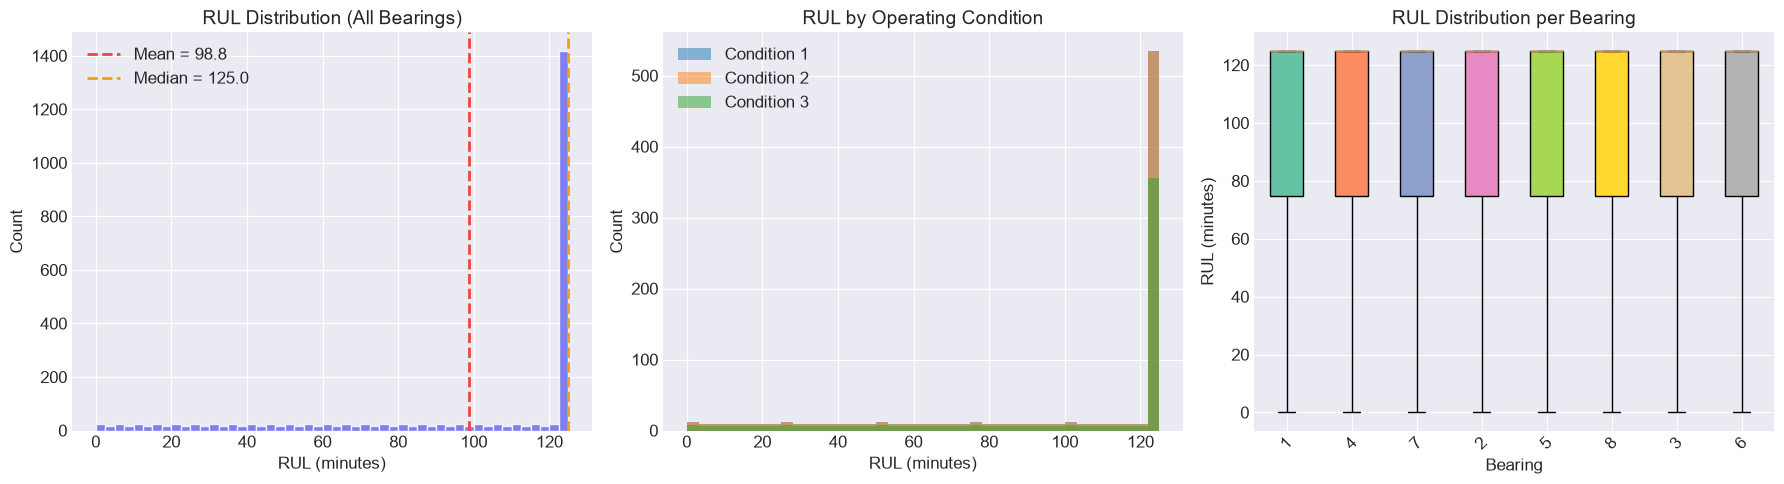

📊 Saved: rul_distribution.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall RUL distribution
axes[0].hist(df['rul'], bins=50, color=COLORS['primary'], alpha=0.8, edgecolor='white')
axes[0].axvline(df['rul'].mean(), color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Mean = {df["rul"].mean():.1f}')
axes[0].axvline(df['rul'].median(), color=COLORS['warning'], linestyle='--', linewidth=2, label=f'Median = {df["rul"].median():.1f}')
axes[0].set_xlabel('RUL (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('RUL Distribution (All Bearings)')
axes[0].legend()

# RUL by operating condition
for cond in sorted(df['operating_condition'].unique()):
    subset = df[df['operating_condition'] == cond]
    axes[1].hist(subset['rul'], bins=40, alpha=0.5, label=f'Condition {cond}')
axes[1].set_xlabel('RUL (minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title('RUL by Operating Condition')
axes[1].legend()

# RUL boxplot per bearing
bearing_names = sorted(df['bearing_name'].unique())
data_for_box = [df[df['bearing_name'] == b]['rul'].values for b in bearing_names]
bp = axes[2].boxplot(data_for_box, patch_artist=True, tick_labels=[b.split('_')[-1] if 'Synthetic' in b else b for b in bearing_names])
colors_box = plt.cm.Set2(np.linspace(0, 1, len(bearing_names)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
axes[2].set_xlabel('Bearing')
axes[2].set_ylabel('RUL (minutes)')
axes[2].set_title('RUL Distribution per Bearing')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: rul_distribution.png")

### 3.2 Feature Degradation Over Bearing Lifecycle

Key vibration features should increase as the bearing degrades (RUL decreases).

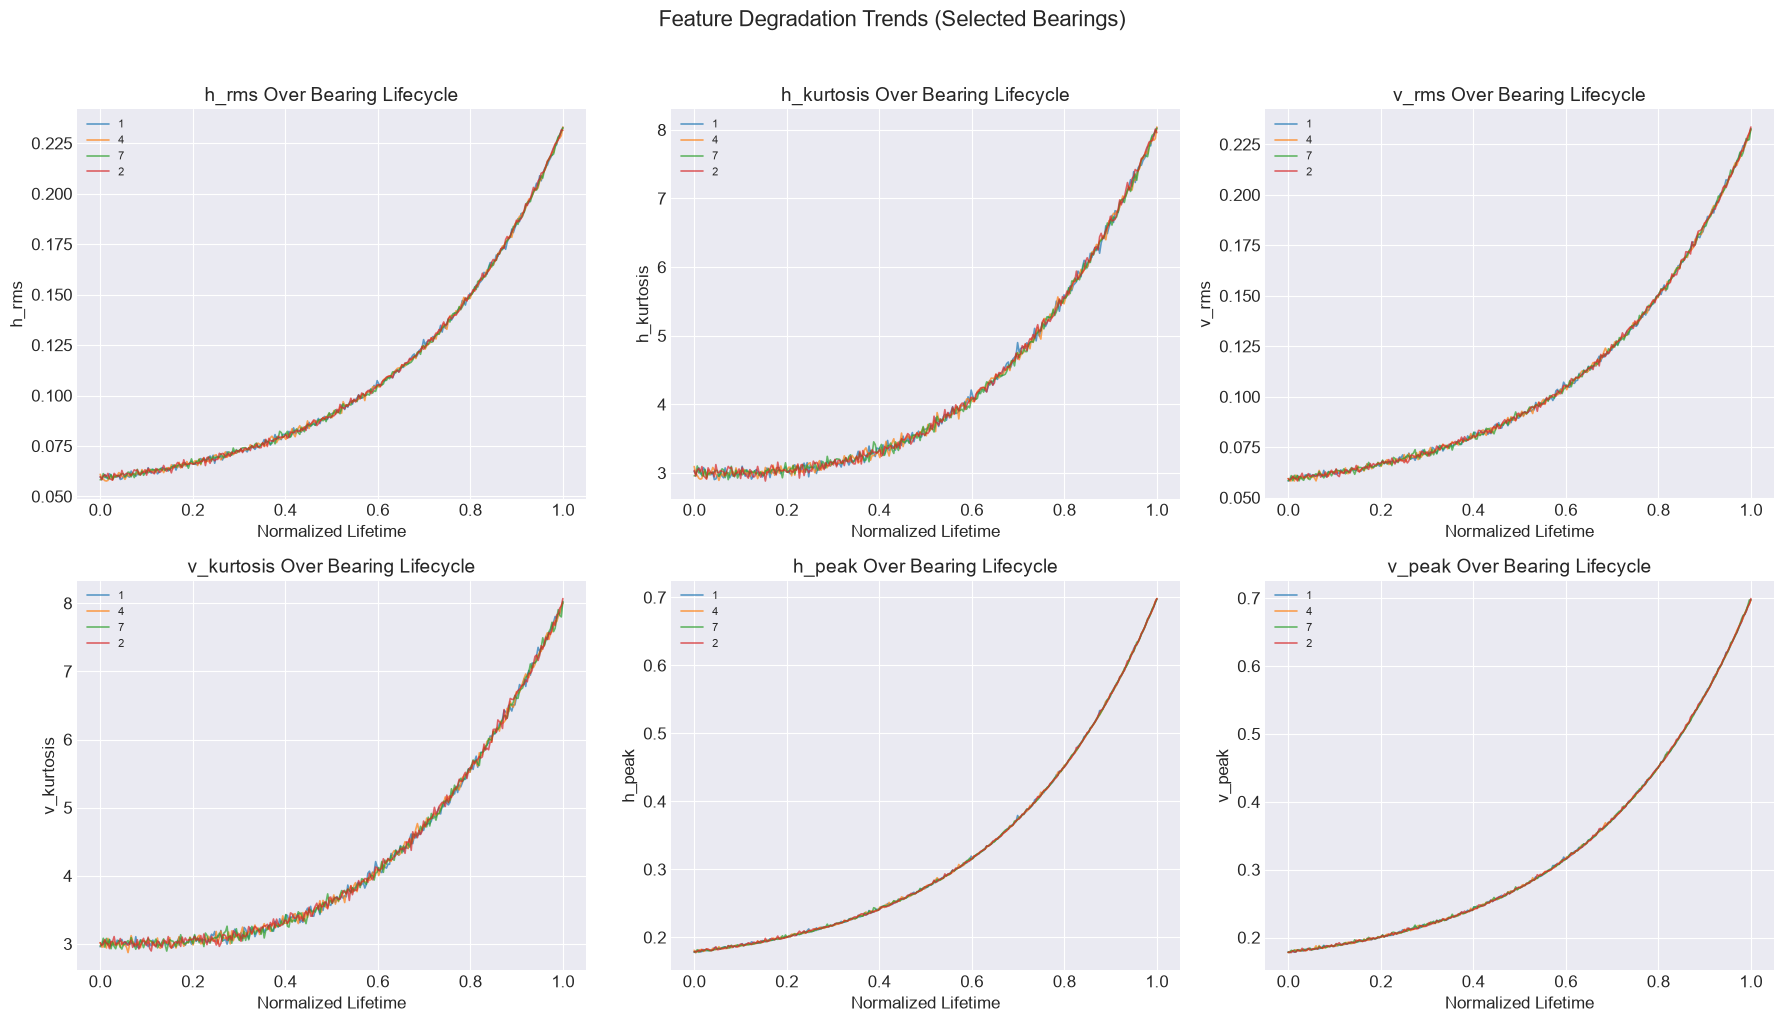

📊 Saved: feature_degradation.png


In [13]:
key_features = ['h_rms', 'h_kurtosis', 'v_rms', 'v_kurtosis', 'h_peak', 'v_peak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    ax = axes[idx]
    for bearing in sorted(df['bearing_name'].unique())[:4]:  # Show first 4 bearings
        subset = df[df['bearing_name'] == bearing].sort_values('normalized_time')
        ax.plot(subset['normalized_time'], subset[feat], alpha=0.7, linewidth=1.2, label=bearing.split('_')[-1])
    ax.set_xlabel('Normalized Lifetime')
    ax.set_ylabel(feat)
    ax.set_title(f'{feat} Over Bearing Lifecycle')
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Feature Degradation Trends (Selected Bearings)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('feature_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: feature_degradation.png")

### 3.3 Feature Correlation Heatmap

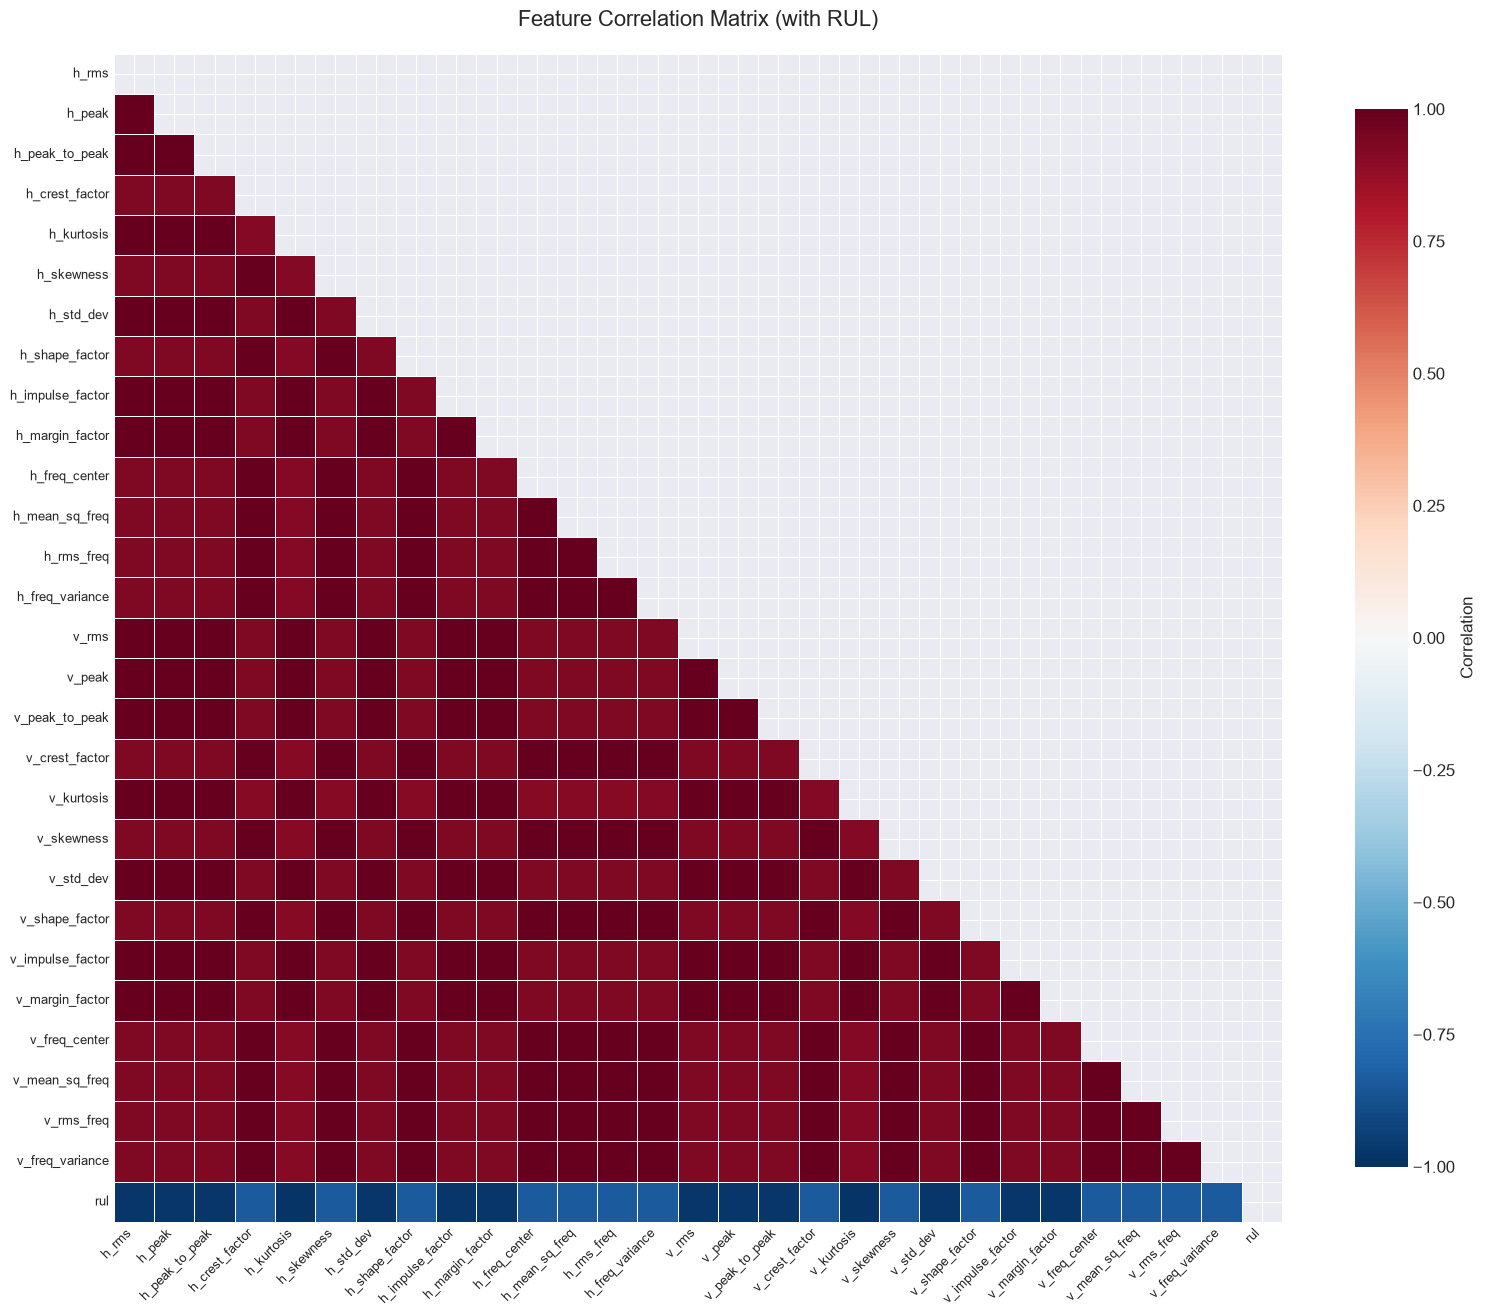

📊 Saved: correlation_heatmap.png


In [14]:
corr_features = FEATURE_NAMES + ['rul']
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    ax=ax
)
ax.set_title('Feature Correlation Matrix (with RUL)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: correlation_heatmap.png")

### 3.4 Top Features Correlated with RUL

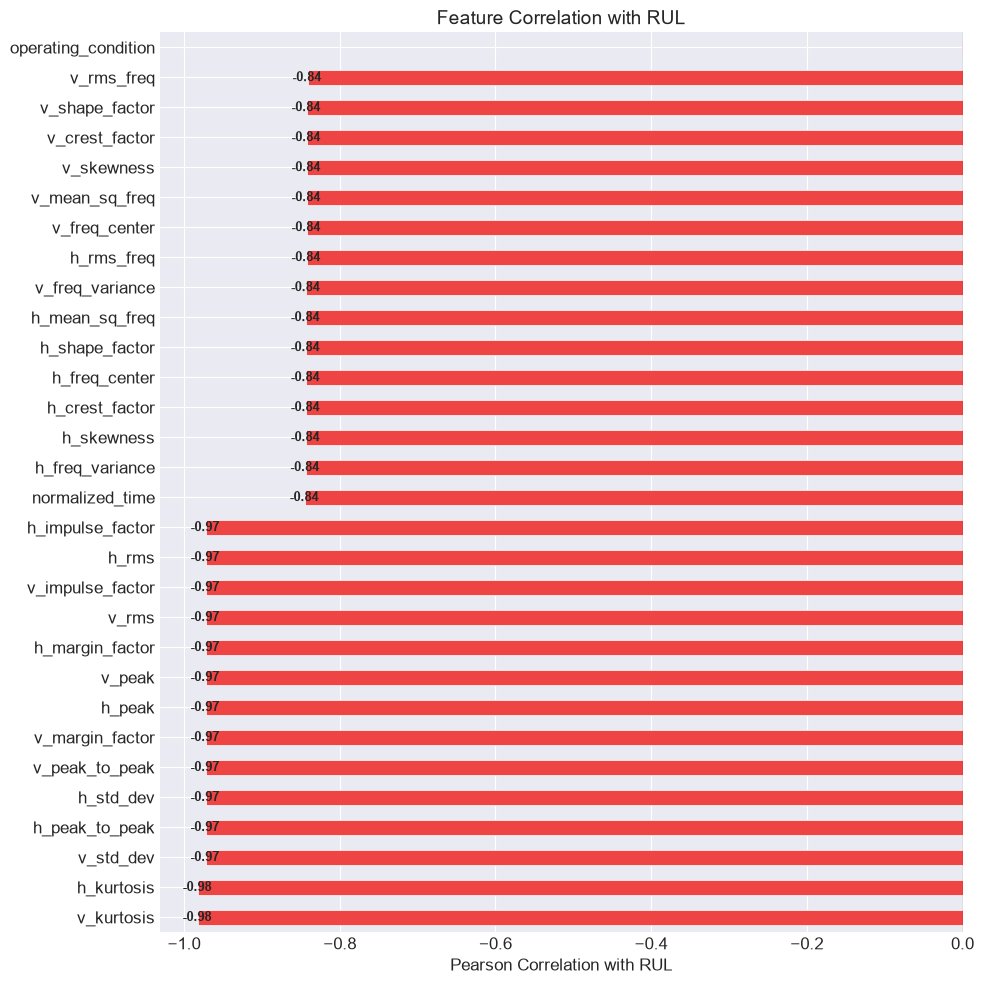

📊 Saved: feature_rul_correlation.png


In [15]:
rul_corr = df[FEATURE_NAMES + ['operating_condition', 'normalized_time', 'rul']].corr()['rul'].drop('rul').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = [COLORS['danger'] if v < 0 else COLORS['success'] for v in rul_corr.values]
rul_corr.plot(kind='barh', color=colors, ax=ax, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Pearson Correlation with RUL')
ax.set_title('Feature Correlation with RUL', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.8)

# Highlight strong correlations
for i, (val, name) in enumerate(zip(rul_corr.values, rul_corr.index)):
    if abs(val) > 0.5:
        ax.text(val + 0.02 * np.sign(val), i, f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_rul_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: feature_rul_correlation.png")

### 3.5 Feature Distributions by Health Status

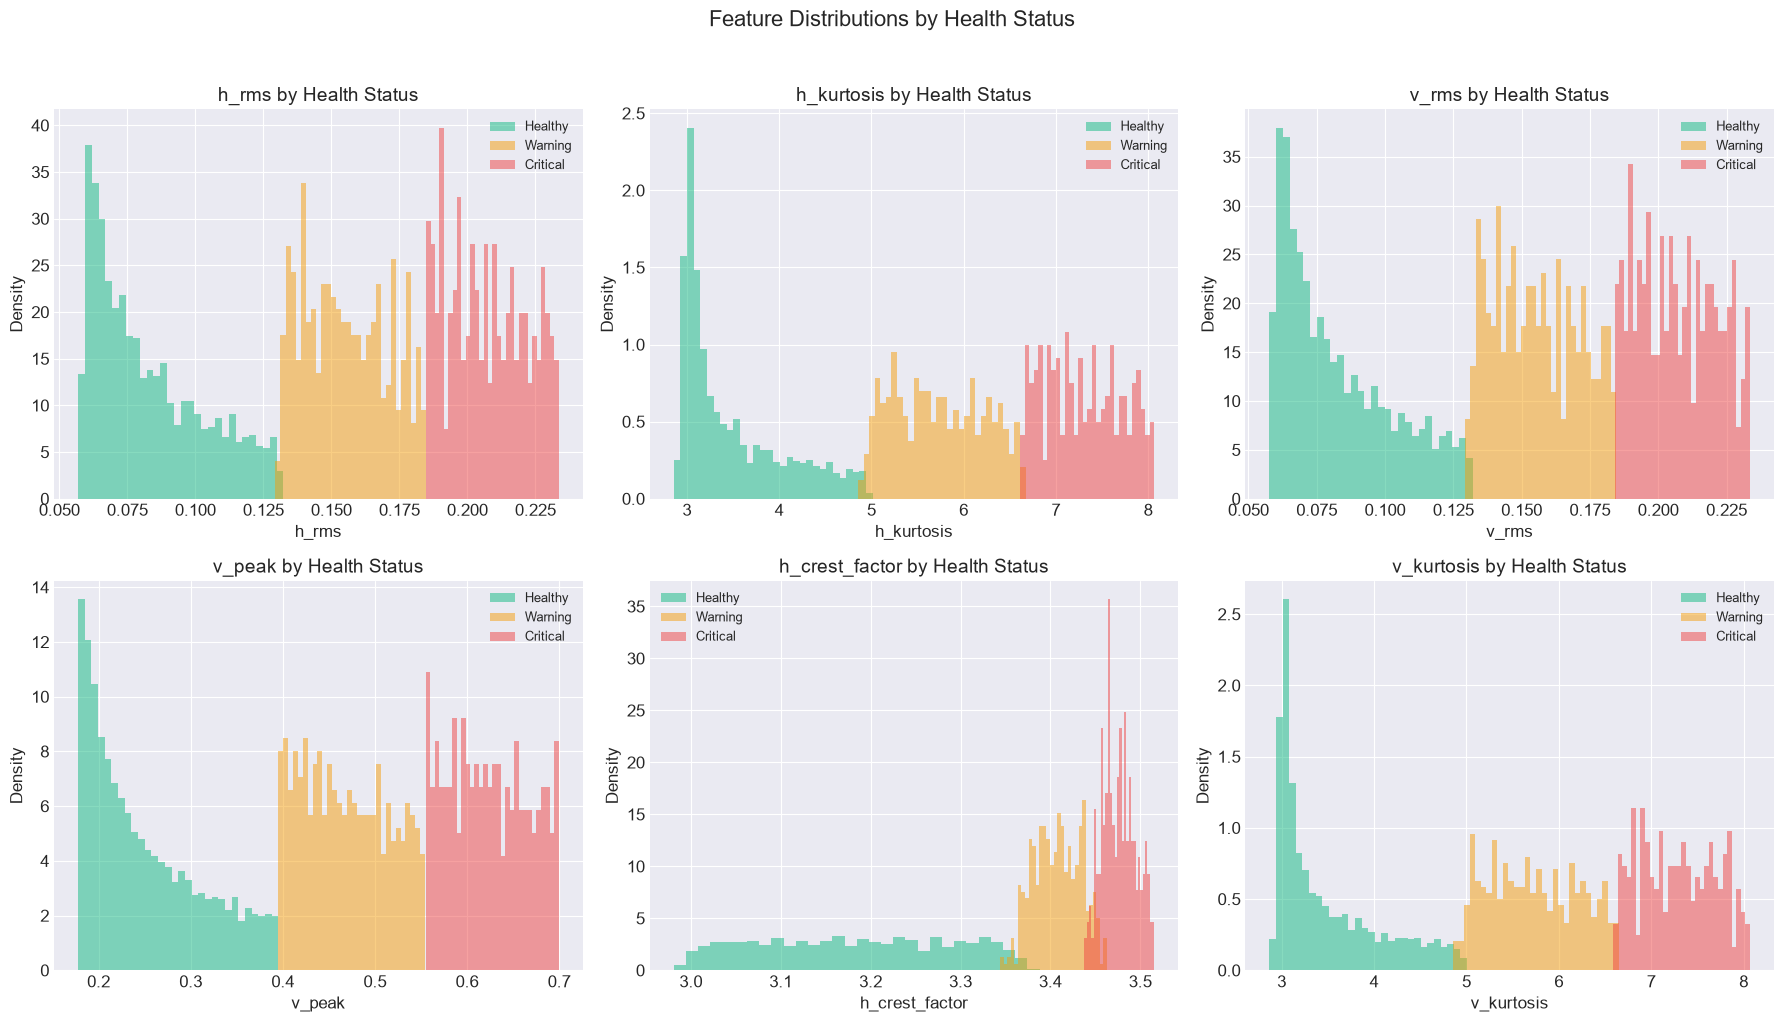

📊 Saved: features_by_health.png


In [16]:
# Classify health status based on RUL thresholds (same as production app)
def classify_health(rul):
    if rul > 80:
        return 'Healthy'
    elif rul > 30:
        return 'Warning'
    else:
        return 'Critical'

df['health_status'] = df['rul'].apply(classify_health)

health_colors = {'Healthy': COLORS['success'], 'Warning': COLORS['warning'], 'Critical': COLORS['danger']}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_features = ['h_rms', 'h_kurtosis', 'v_rms', 'v_peak', 'h_crest_factor', 'v_kurtosis']
for idx, feat in enumerate(plot_features):
    ax = axes[idx]
    for status in ['Healthy', 'Warning', 'Critical']:
        subset = df[df['health_status'] == status]
        ax.hist(subset[feat], bins=30, alpha=0.5, label=status, color=health_colors[status], density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(f'{feat} by Health Status')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Health Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('features_by_health.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: features_by_health.png")

---

## 4. Model Training

Train an XGBoost regressor using the same pipeline as the production application.

In [17]:
# Prepare features and target
feature_cols = get_training_features()
print(f"Training features ({len(feature_cols)}):")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")

X = df[feature_cols].values
y = df['rul'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\n🔀 Train/Test Split:")
print(f"   Train: {X_train.shape[0]} samples")
print(f"   Test:  {X_test.shape[0]} samples")

Training features (30):
   1. h_rms
   2. h_peak
   3. h_peak_to_peak
   4. h_crest_factor
   5. h_kurtosis
   6. h_skewness
   7. h_std_dev
   8. h_shape_factor
   9. h_impulse_factor
  10. h_margin_factor
  11. h_freq_center
  12. h_mean_sq_freq
  13. h_rms_freq
  14. h_freq_variance
  15. v_rms
  16. v_peak
  17. v_peak_to_peak
  18. v_crest_factor
  19. v_kurtosis
  20. v_skewness
  21. v_std_dev
  22. v_shape_factor
  23. v_impulse_factor
  24. v_margin_factor
  25. v_freq_center
  26. v_mean_sq_freq
  27. v_rms_freq
  28. v_freq_variance
  29. operating_condition
  30. normalized_time

🔀 Train/Test Split:
   Train: 1920 samples
   Test:  480 samples


In [18]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
print("🚀 Training XGBoost Regressor...\n")

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=RANDOM_STATE,
    objective='reg:squarederror',
    eval_metric='rmse',
)

# Train with evaluation set for learning curve
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=50,
)

print("\n✅ Training complete!")

🚀 Training XGBoost Regressor...

[0]	validation_0-rmse:34.90275	validation_1-rmse:35.38660
[50]	validation_0-rmse:0.24140	validation_1-rmse:0.34990
[100]	validation_0-rmse:0.07133	validation_1-rmse:0.22397
[150]	validation_0-rmse:0.05049	validation_1-rmse:0.21939
[200]	validation_0-rmse:0.03827	validation_1-rmse:0.21597
[250]	validation_0-rmse:0.03157	validation_1-rmse:0.21420
[299]	validation_0-rmse:0.02605	validation_1-rmse:0.21304

✅ Training complete!


### 4.1 Learning Curves

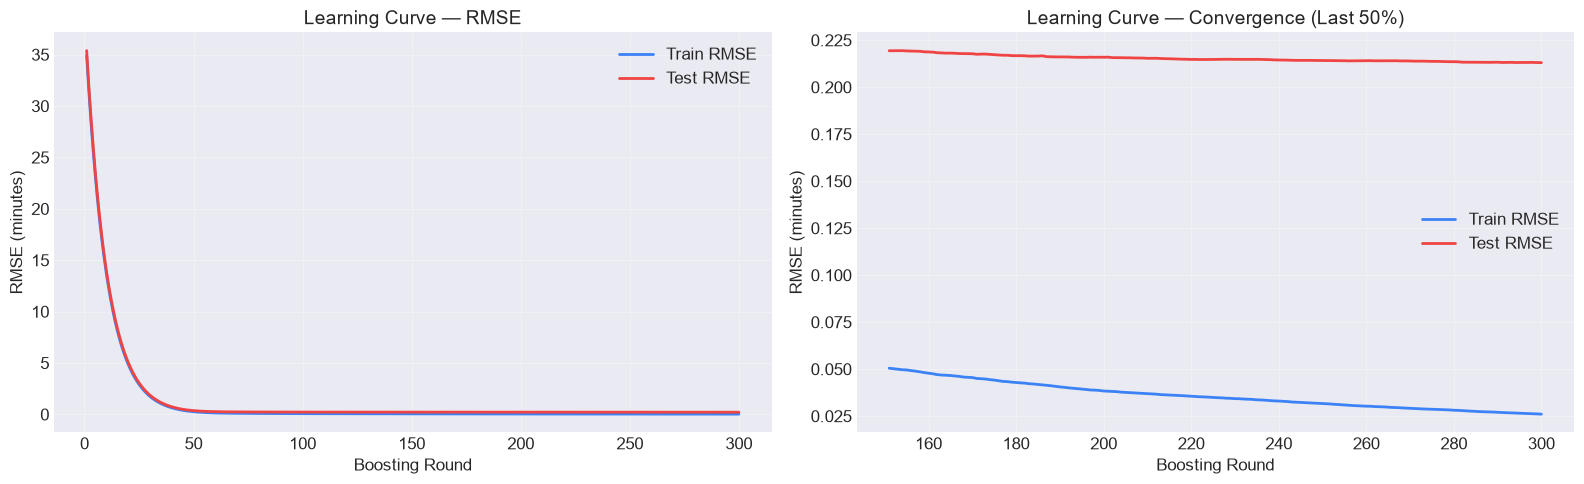

📊 Saved: learning_curves.png


In [19]:
# Plot learning curves
results = model.evals_result()
train_rmse = results['validation_0']['rmse']
test_rmse = results['validation_1']['rmse']
epochs = range(1, len(train_rmse) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RMSE over epochs
axes[0].plot(epochs, train_rmse, label='Train RMSE', color=COLORS['info'], linewidth=2)
axes[0].plot(epochs, test_rmse, label='Test RMSE', color=COLORS['danger'], linewidth=2)
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('RMSE (minutes)')
axes[0].set_title('Learning Curve — RMSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Convergence zoom (last 50%)
start = len(train_rmse) // 2
axes[1].plot(list(epochs)[start:], train_rmse[start:], label='Train RMSE', color=COLORS['info'], linewidth=2)
axes[1].plot(list(epochs)[start:], test_rmse[start:], label='Test RMSE', color=COLORS['danger'], linewidth=2)
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('RMSE (minutes)')
axes[1].set_title('Learning Curve — Convergence (Last 50%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: learning_curves.png")

---

## 5. Model Evaluation & Scores

In [20]:
# Generate predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Compute all metrics
def compute_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    residuals = y_true - y_pred
    max_err = np.max(np.abs(residuals))
    median_ae = np.median(np.abs(residuals))
    mean_res = np.mean(residuals)
    std_res = np.std(residuals)
    
    # MAPE (handle zeros)
    nonzero_mask = y_true > 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs(residuals[nonzero_mask]) / y_true[nonzero_mask]) * 100
    else:
        mape = float('nan')
    
    return {
        'Set': label,
        'Samples': len(y_true),
        'R²': r2,
        'RMSE (min)': rmse,
        'MAE (min)': mae,
        'Median AE (min)': median_ae,
        'Max Error (min)': max_err,
        'MAPE (%)': mape,
        'Mean Residual': mean_res,
        'Std Residual': std_res,
    }

train_metrics = compute_metrics(y_train, y_pred_train, 'Train')
test_metrics = compute_metrics(y_test, y_pred_test, 'Test')

# Full dataset
X_all_scaled = scaler.transform(X)
y_pred_all = model.predict(X_all_scaled)
all_metrics = compute_metrics(y, y_pred_all, 'Full')

metrics_df = pd.DataFrame([train_metrics, test_metrics, all_metrics])
metrics_df = metrics_df.set_index('Set')

print("\n" + "="*70)
print("                    MODEL EVALUATION SCORES")
print("="*70)
metrics_df.style.format({
    'R²': '{:.6f}',
    'RMSE (min)': '{:.4f}',
    'MAE (min)': '{:.4f}',
    'Median AE (min)': '{:.4f}',
    'Max Error (min)': '{:.4f}',
    'MAPE (%)': '{:.2f}',
    'Mean Residual': '{:.4f}',
    'Std Residual': '{:.4f}',
}).background_gradient(cmap='RdYlGn', subset=['R²']).background_gradient(cmap='RdYlGn_r', subset=['RMSE (min)', 'MAE (min)'])


                    MODEL EVALUATION SCORES


,Samples,R²,RMSE (min),MAE (min),Median AE (min),Max Error (min),MAPE (%),Mean Residual,Std Residual
Set,,,,,,,,,
Train,1920,1.000000,0.0261,0.0119,0.0002,0.2104,0.05,-0.0000,0.0261
Test,480,0.999970,0.2130,0.0918,0.0002,1.2452,0.54,-0.0238,0.2117
Full,2400,0.999994,0.0981,0.0279,0.0002,1.2452,0.15,-0.0048,0.0980


In [21]:
# Print quality verdict
r2_test = test_metrics['R²']
print(f"\n{'='*50}")
print(f"  TEST R² = {r2_test:.6f}")
if r2_test >= 0.95:
    print("  ⭐⭐⭐⭐⭐ EXCELLENT — Model generalizes very well")
elif r2_test >= 0.90:
    print("  ⭐⭐⭐⭐  GOOD — Model generalizes well")
elif r2_test >= 0.80:
    print("  ⭐⭐⭐   FAIR — Model may benefit from more data or tuning")
elif r2_test >= 0.60:
    print("  ⭐⭐    POOR — Significant improvement needed")
else:
    print("  ⭐     VERY POOR — Model needs substantial rework")
print(f"{'='*50}")


  TEST R² = 0.999970
  ⭐⭐⭐⭐⭐ EXCELLENT — Model generalizes very well


### 5.1 Actual vs Predicted RUL

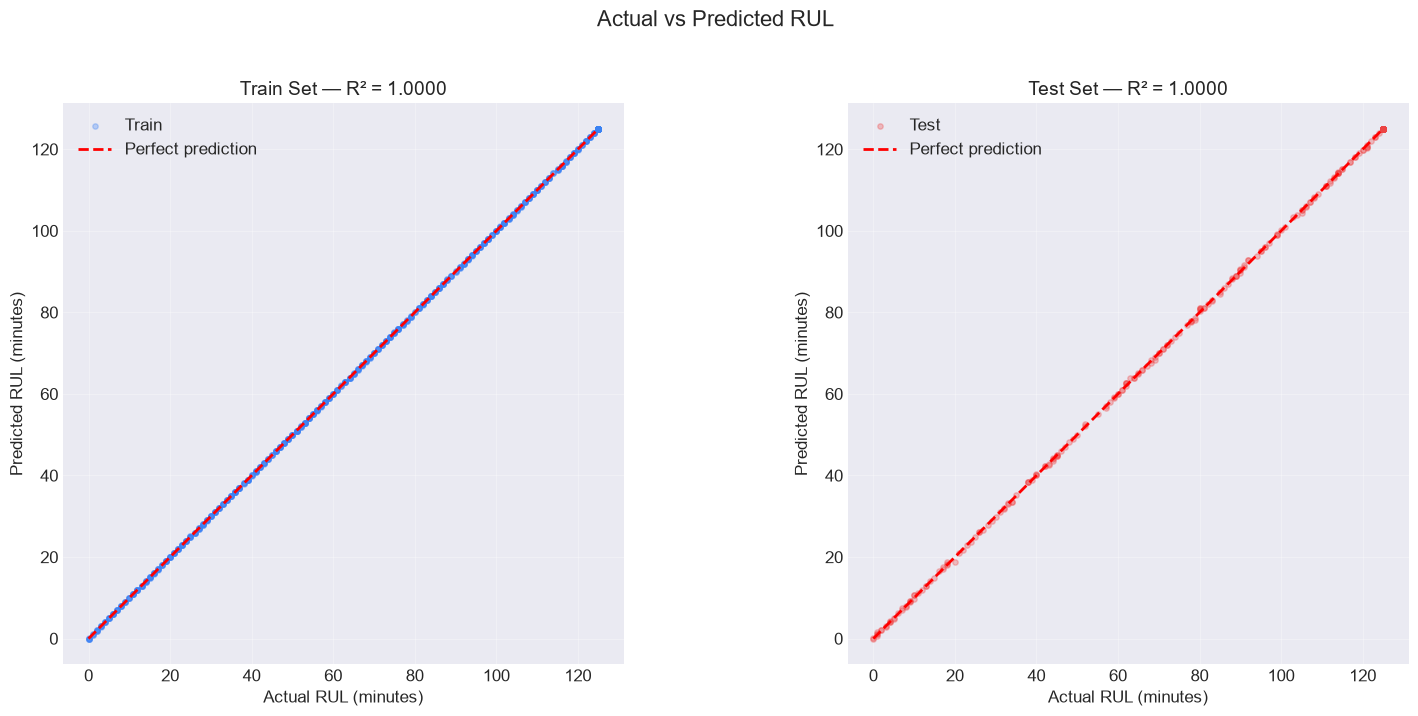

📊 Saved: actual_vs_predicted.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Train set
axes[0].scatter(y_train, y_pred_train, alpha=0.3, s=15, color=COLORS['info'], label='Train')
axes[0].plot([0, y.max()], [0, y.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual RUL (minutes)')
axes[0].set_ylabel('Predicted RUL (minutes)')
axes[0].set_title(f'Train Set — R² = {train_metrics["R²"]:.4f}')
axes[0].legend()
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_pred_test, alpha=0.3, s=15, color=COLORS['danger'], label='Test')
axes[1].plot([0, y.max()], [0, y.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual RUL (minutes)')
axes[1].set_ylabel('Predicted RUL (minutes)')
axes[1].set_title(f'Test Set — R² = {test_metrics["R²"]:.4f}')
axes[1].legend()
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted RUL', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: actual_vs_predicted.png")

### 5.2 Residual Analysis

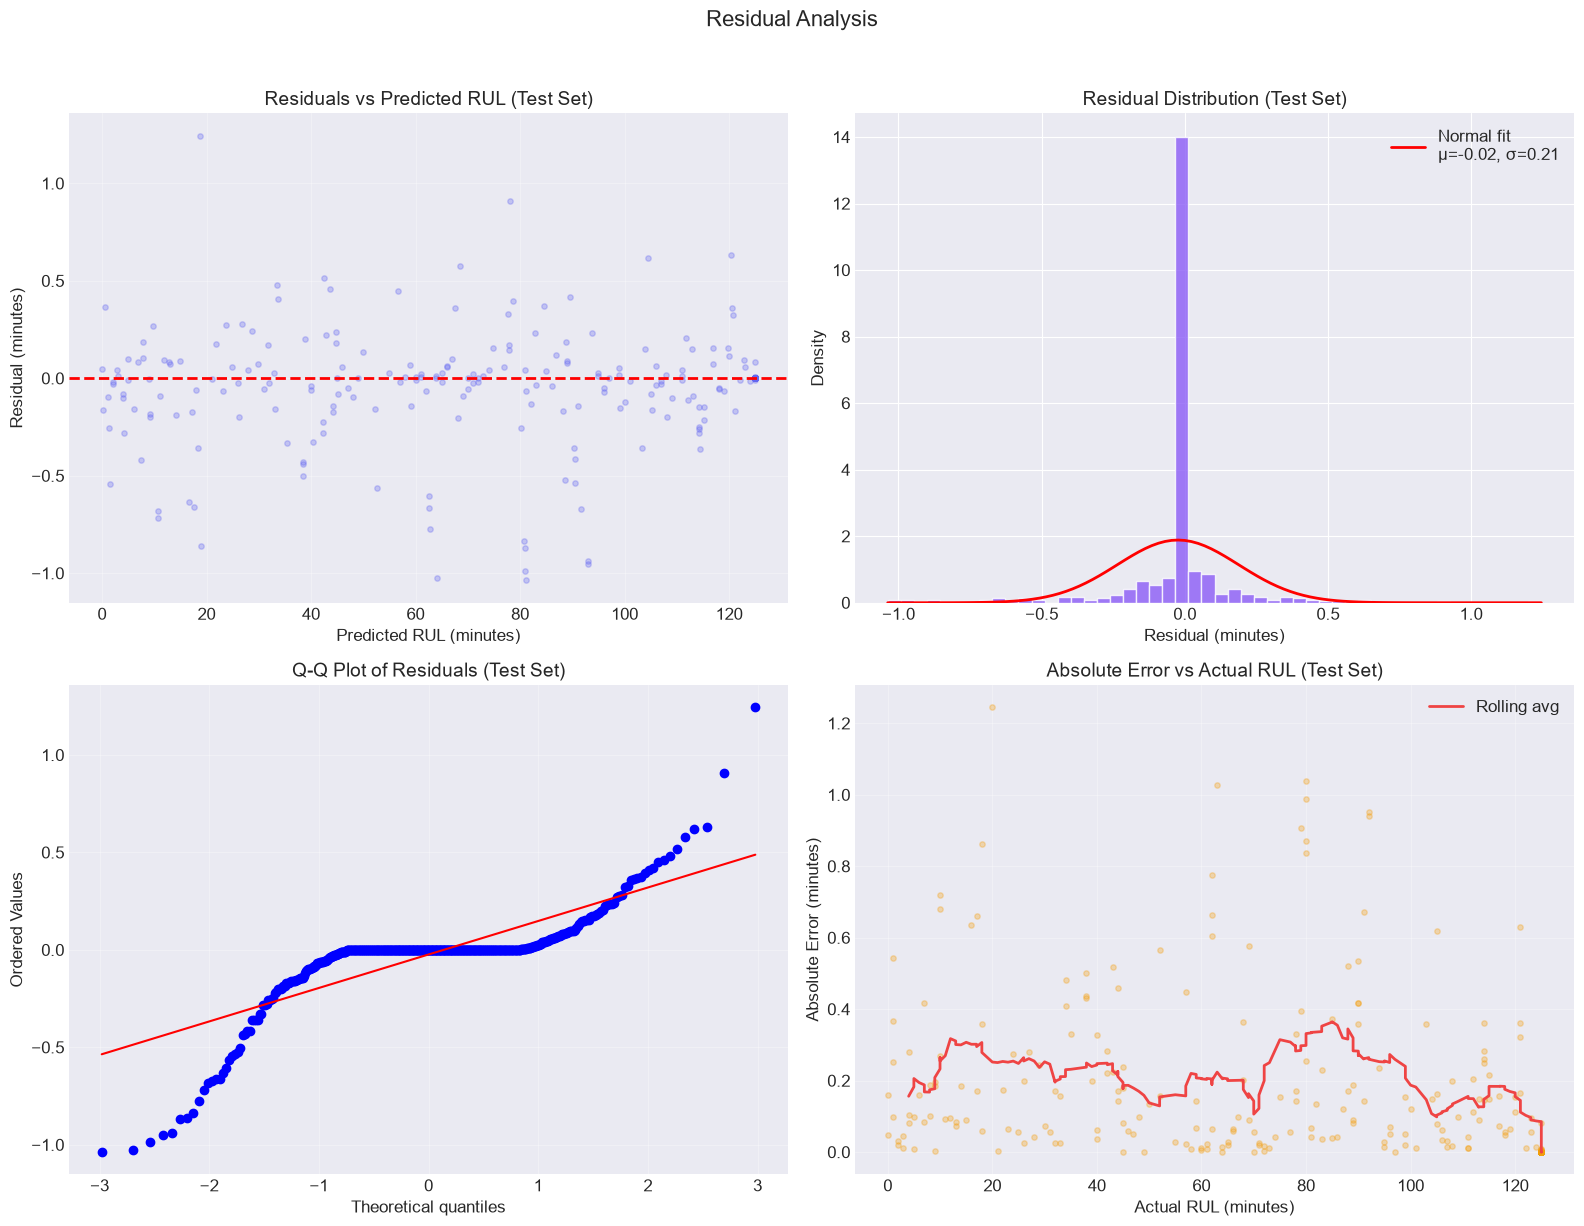

📊 Saved: residual_analysis.png


In [23]:
residuals_test = y_test - y_pred_test
residuals_train = y_train - y_pred_train

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Residuals vs Predicted (Test)
axes[0, 0].scatter(y_pred_test, residuals_test, alpha=0.3, s=15, color=COLORS['primary'])
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted RUL (minutes)')
axes[0, 0].set_ylabel('Residual (minutes)')
axes[0, 0].set_title('Residuals vs Predicted RUL (Test Set)')
axes[0, 0].grid(True, alpha=0.3)

# Residual histogram (Test)
axes[0, 1].hist(residuals_test, bins=50, color=COLORS['secondary'], alpha=0.8, edgecolor='white', density=True)
# Overlay normal distribution
x_norm = np.linspace(residuals_test.min(), residuals_test.max(), 100)
from scipy.stats import norm
mu, std = norm.fit(residuals_test)
axes[0, 1].plot(x_norm, norm.pdf(x_norm, mu, std), 'r-', linewidth=2, label=f'Normal fit\nμ={mu:.2f}, σ={std:.2f}')
axes[0, 1].set_xlabel('Residual (minutes)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Residual Distribution (Test Set)')
axes[0, 1].legend()

# QQ Plot
from scipy import stats as sp_stats
sp_stats.probplot(residuals_test, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals (Test Set)')
axes[1, 0].grid(True, alpha=0.3)

# Absolute error vs Actual RUL
abs_errors = np.abs(residuals_test)
axes[1, 1].scatter(y_test, abs_errors, alpha=0.3, s=15, color=COLORS['warning'])
# Rolling average
sort_idx = np.argsort(y_test)
window = max(1, len(y_test) // 20)
rolling_mean = pd.Series(abs_errors[sort_idx]).rolling(window=window, center=True).mean()
axes[1, 1].plot(y_test[sort_idx], rolling_mean, color=COLORS['danger'], linewidth=2, label='Rolling avg')
axes[1, 1].set_xlabel('Actual RUL (minutes)')
axes[1, 1].set_ylabel('Absolute Error (minutes)')
axes[1, 1].set_title('Absolute Error vs Actual RUL (Test Set)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: residual_analysis.png")

### 5.3 Feature Importance

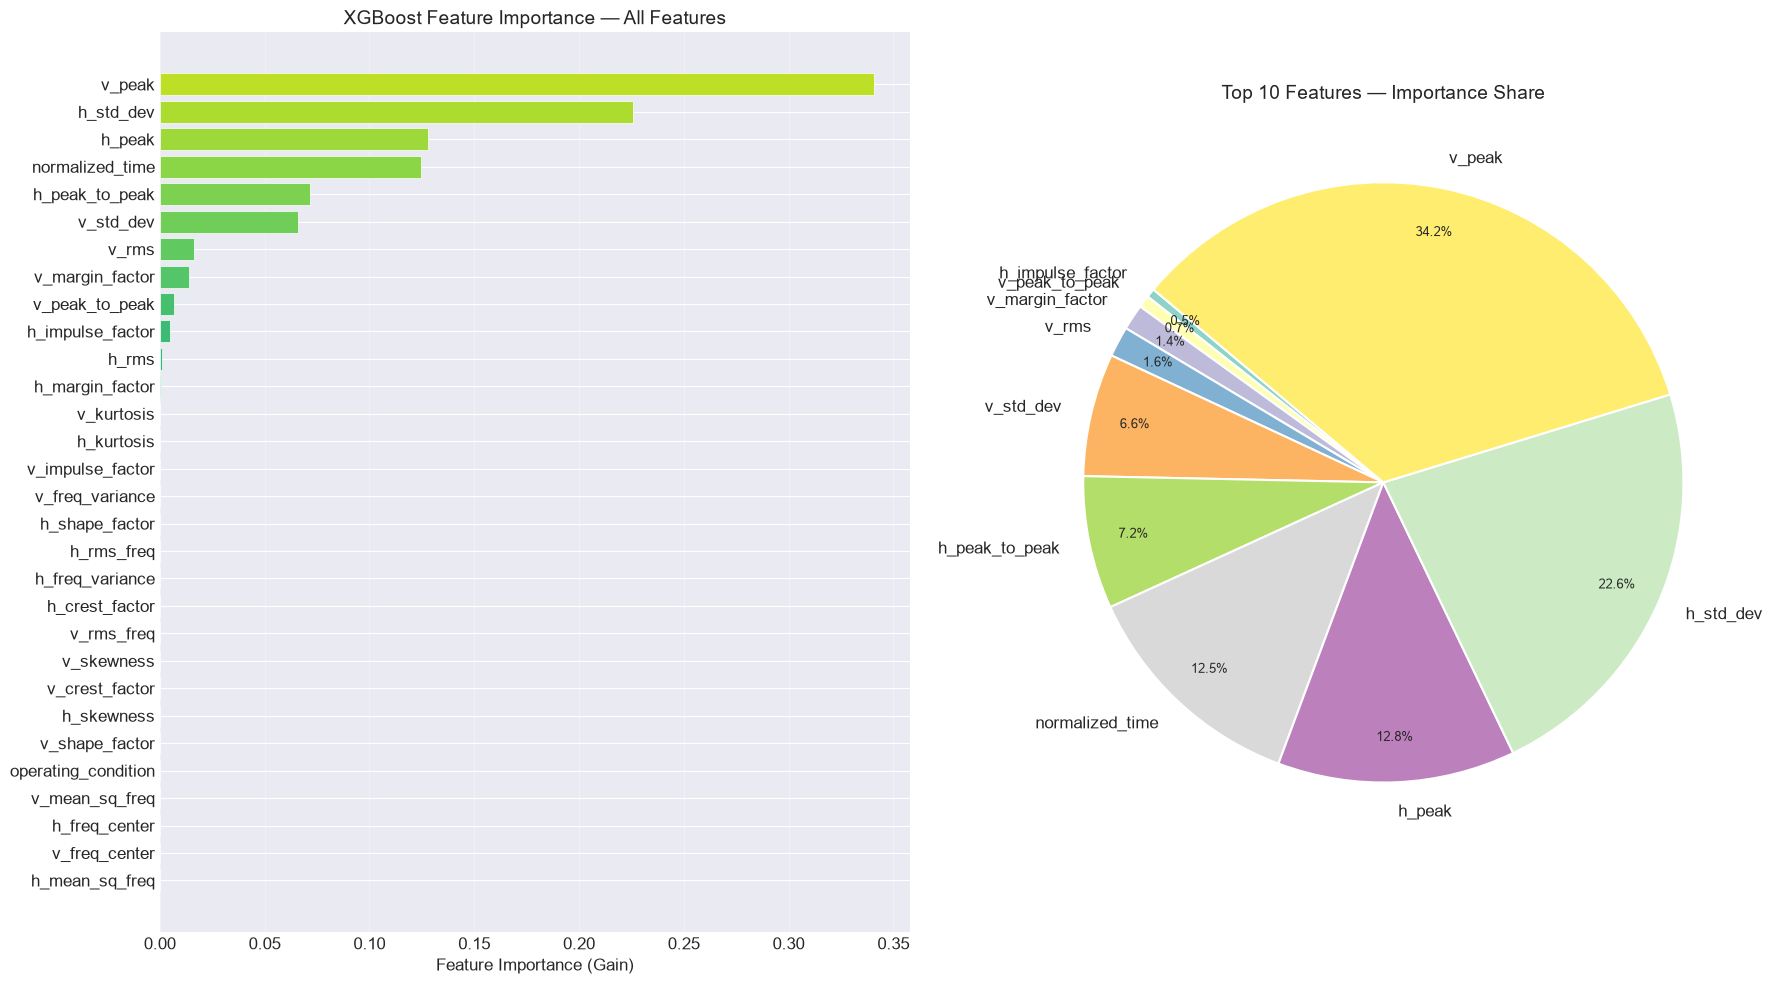

📊 Saved: feature_importance.png


In [24]:
# Feature importance from the trained model
importances = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Horizontal bar chart
colors_imp = plt.cm.viridis(np.linspace(0.2, 0.9, len(importance_df)))
axes[0].barh(importance_df['Feature'], importance_df['Importance'], color=colors_imp, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Feature Importance (Gain)')
axes[0].set_title('XGBoost Feature Importance — All Features')
axes[0].grid(axis='x', alpha=0.3)

# Top 10 pie chart
top10 = importance_df.tail(10)
pie_colors = plt.cm.Set3(np.linspace(0, 1, 10))
wedges, texts, autotexts = axes[1].pie(
    top10['Importance'], labels=top10['Feature'],
    autopct='%1.1f%%', colors=pie_colors,
    startangle=140, pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)
axes[1].set_title('Top 10 Features — Importance Share')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: feature_importance.png")

### 5.4 Per-Bearing Evaluation

In [25]:
# Evaluate model on each bearing individually
bearing_metrics = []

for bearing_name in sorted(df['bearing_name'].unique()):
    subset = df[df['bearing_name'] == bearing_name]
    X_b = scaler.transform(subset[feature_cols].values)
    y_b = subset['rul'].values
    y_pred_b = model.predict(X_b)
    
    bearing_metrics.append({
        'Bearing': bearing_name,
        'Samples': len(y_b),
        'Condition': subset['operating_condition'].iloc[0],
        'R²': r2_score(y_b, y_pred_b),
        'RMSE': np.sqrt(mean_squared_error(y_b, y_pred_b)),
        'MAE': mean_absolute_error(y_b, y_pred_b),
        'Max Error': np.max(np.abs(y_b - y_pred_b)),
    })

bearing_df = pd.DataFrame(bearing_metrics)
bearing_df = bearing_df.set_index('Bearing')

print("\nPer-Bearing Metrics:")
bearing_df.style.format({
    'R²': '{:.4f}',
    'RMSE': '{:.2f}',
    'MAE': '{:.2f}',
    'Max Error': '{:.2f}',
}).background_gradient(cmap='RdYlGn', subset=['R²']).background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE'])


Per-Bearing Metrics:


,Samples,Condition,R²,RMSE,MAE,Max Error
Bearing,,,,,,
Synthetic_1_1,300,1,1.0000,0.14,0.04,1.25
Synthetic_1_4,300,1,1.0000,0.08,0.02,0.66
Synthetic_1_7,300,1,1.0000,0.11,0.03,1.03
Synthetic_2_2,300,2,1.0000,0.10,0.03,0.95
Synthetic_2_5,300,2,1.0000,0.06,0.02,0.56
Synthetic_2_8,300,2,1.0000,0.08,0.02,0.94
Synthetic_3_3,300,3,1.0000,0.09,0.03,0.99
Synthetic_3_6,300,3,1.0000,0.10,0.03,0.84


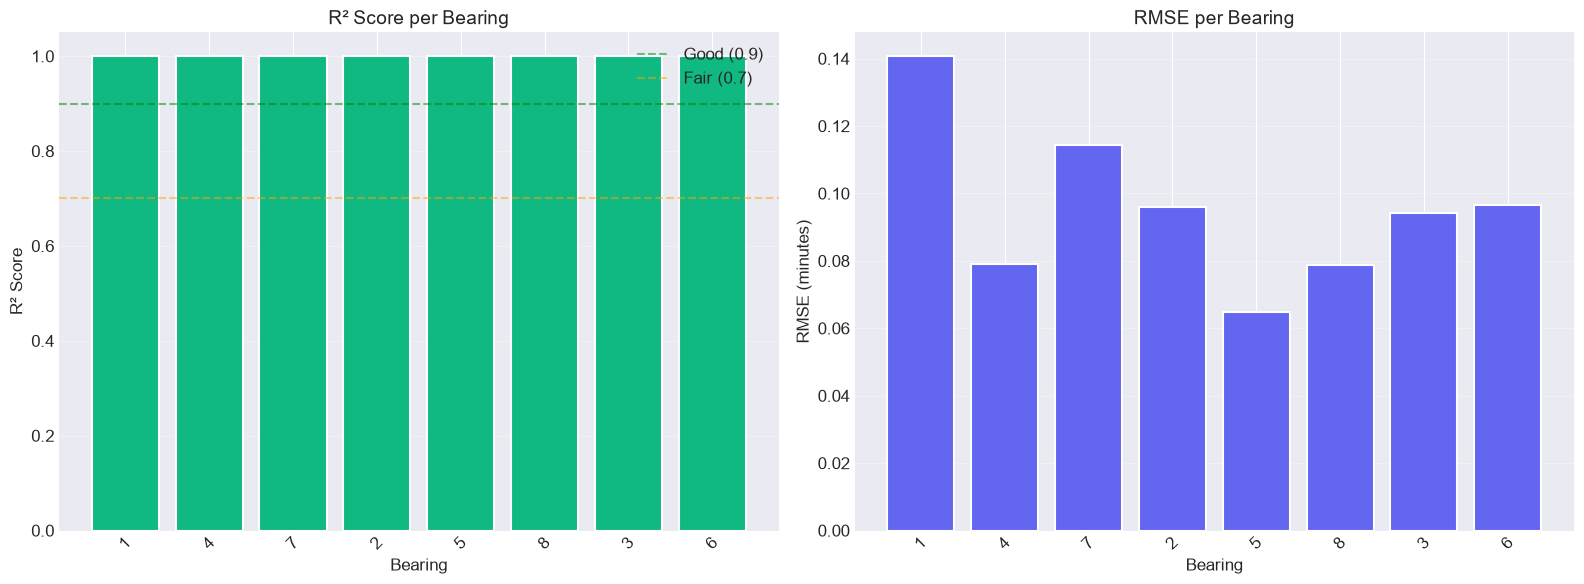

📊 Saved: per_bearing_scores.png


In [26]:
# Visualize per-bearing R² scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² bar chart per bearing
r2_values = bearing_df['R²'].values
bar_colors = [COLORS['success'] if r >= 0.9 else (COLORS['warning'] if r >= 0.7 else COLORS['danger']) for r in r2_values]
short_names = [n.split('_')[-1] if 'Synthetic' in n else n for n in bearing_df.index]
axes[0].bar(short_names, r2_values, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Good (0.9)')
axes[0].axhline(y=0.7, color='orange', linestyle='--', alpha=0.5, label='Fair (0.7)')
axes[0].set_xlabel('Bearing')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score per Bearing')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim([min(0, r2_values.min() - 0.1), 1.05])
axes[0].grid(axis='y', alpha=0.3)

# RMSE bar chart per bearing
rmse_values = bearing_df['RMSE'].values
axes[1].bar(short_names, rmse_values, color=COLORS['primary'], edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Bearing')
axes[1].set_ylabel('RMSE (minutes)')
axes[1].set_title('RMSE per Bearing')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_bearing_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: per_bearing_scores.png")

### 5.5 RUL Prediction Timeline (Selected Bearings)

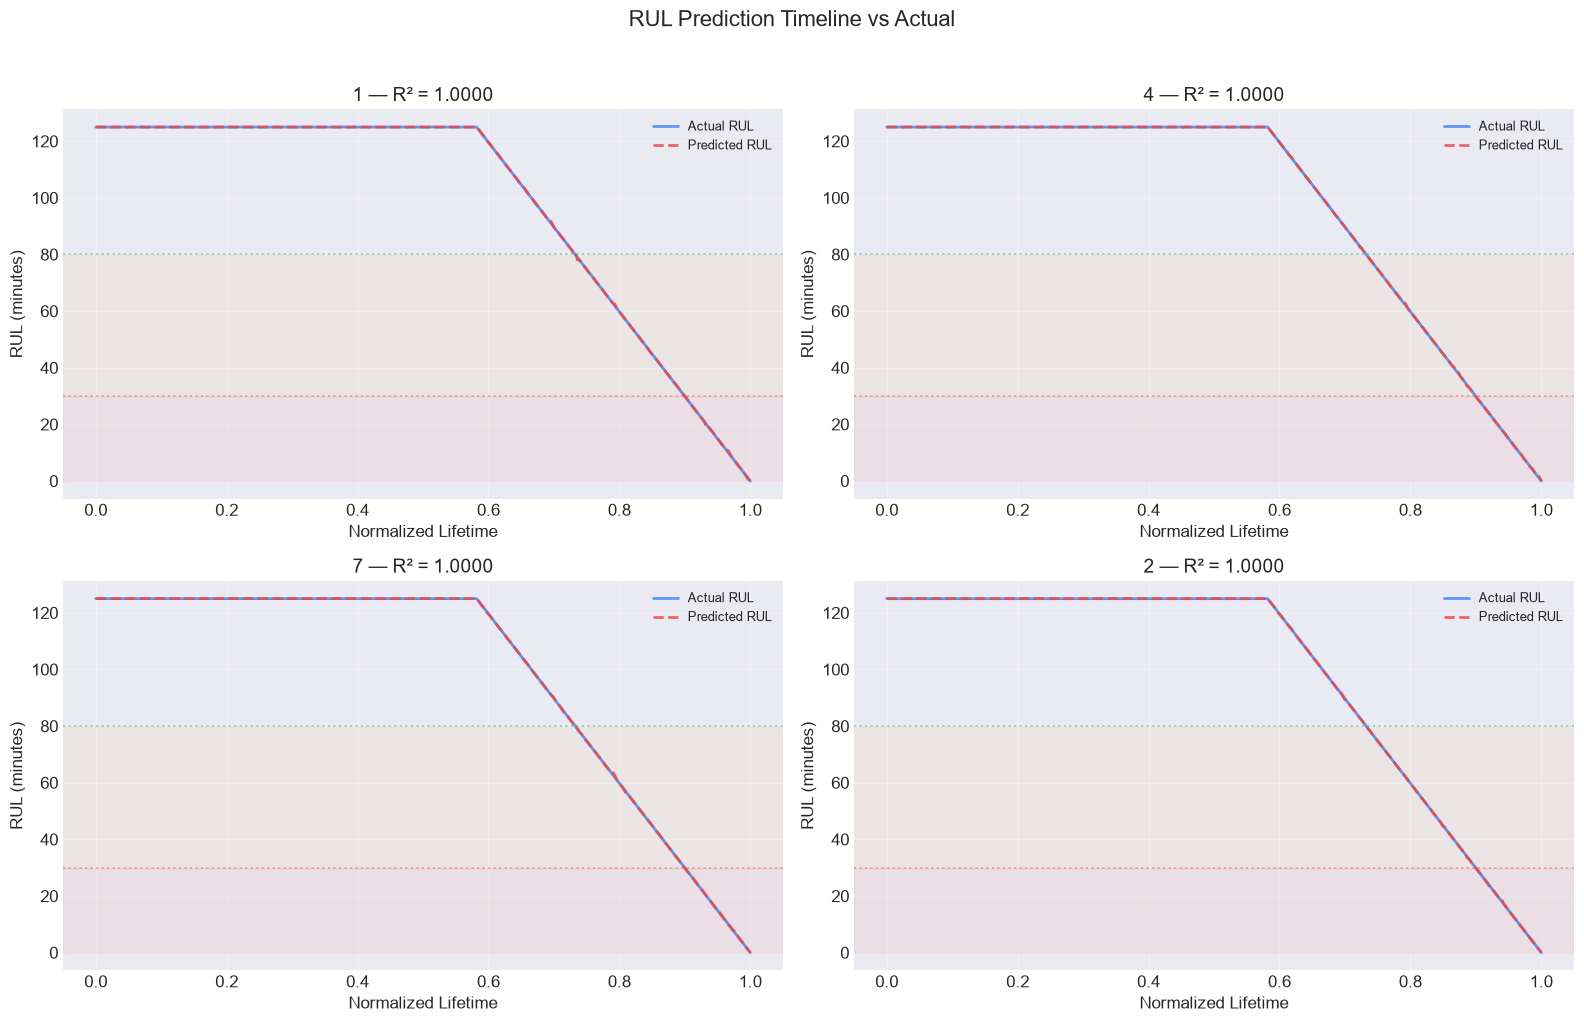

📊 Saved: rul_timeline.png


In [27]:
# Show actual vs predicted RUL over the lifecycle for a few bearings
selected_bearings = sorted(df['bearing_name'].unique())[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, bearing_name in enumerate(selected_bearings):
    ax = axes[idx]
    subset = df[df['bearing_name'] == bearing_name].sort_values('normalized_time')
    X_b = scaler.transform(subset[feature_cols].values)
    y_actual = subset['rul'].values
    y_pred = model.predict(X_b)
    time_axis = subset['normalized_time'].values
    
    ax.plot(time_axis, y_actual, color=COLORS['info'], linewidth=2, label='Actual RUL', alpha=0.8)
    ax.plot(time_axis, y_pred, color=COLORS['danger'], linewidth=2, label='Predicted RUL', linestyle='--', alpha=0.8)
    
    # Shade the error region
    ax.fill_between(time_axis, y_actual, y_pred, alpha=0.15, color=COLORS['warning'])
    
    # Health zones
    ax.axhline(y=80, color=COLORS['success'], linestyle=':', alpha=0.4)
    ax.axhline(y=30, color=COLORS['danger'], linestyle=':', alpha=0.4)
    ax.axhspan(0, 30, alpha=0.05, color='red')
    ax.axhspan(30, 80, alpha=0.05, color='orange')
    
    r2_b = r2_score(y_actual, y_pred)
    ax.set_xlabel('Normalized Lifetime')
    ax.set_ylabel('RUL (minutes)')
    short = bearing_name.split('_')[-1] if 'Synthetic' in bearing_name else bearing_name
    ax.set_title(f'{short} — R² = {r2_b:.4f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('RUL Prediction Timeline vs Actual', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('rul_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: rul_timeline.png")

### 5.6 Error Distribution by Health Zone

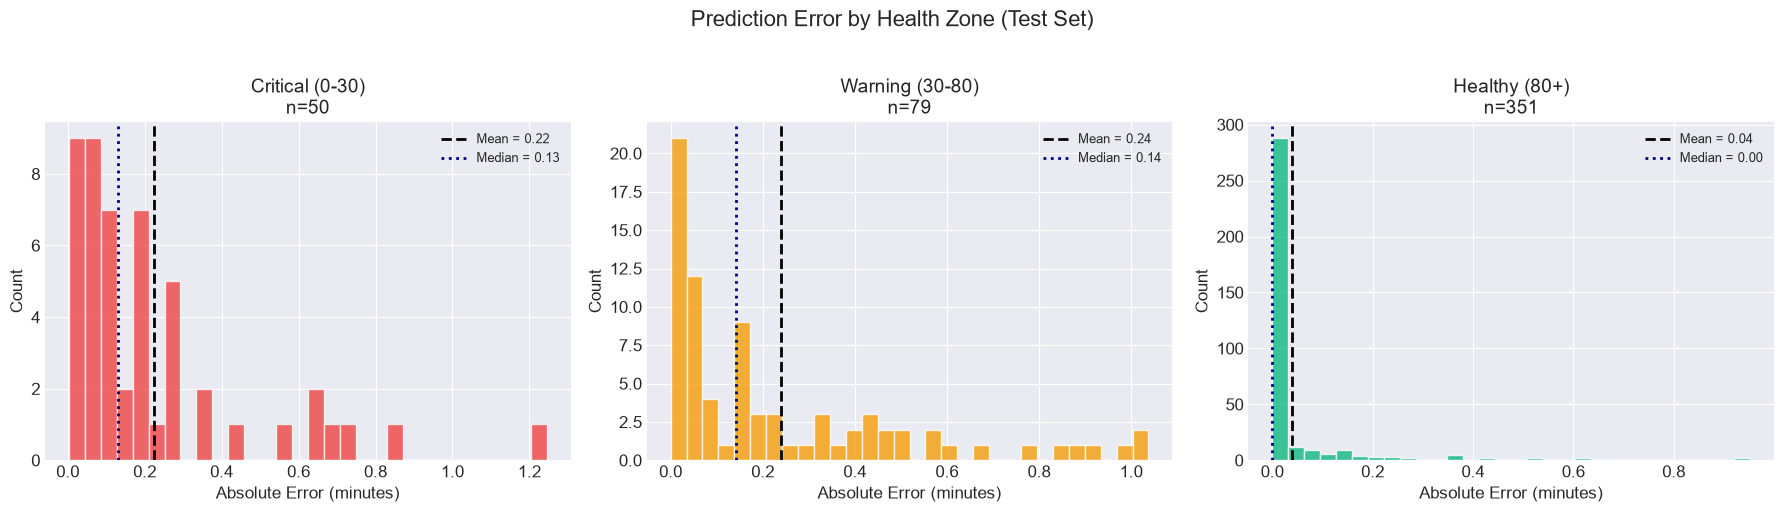

📊 Saved: error_by_health_zone.png


In [28]:
# Analyze errors in different health zones
y_pred_all_test = model.predict(X_test_scaled)
test_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_all_test,
    'abs_error': np.abs(y_test - y_pred_all_test),
    'health_zone': pd.cut(y_test, bins=[-1, 30, 80, 200], labels=['Critical (0-30)', 'Warning (30-80)', 'Healthy (80+)'])
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

zone_colors = {'Critical (0-30)': COLORS['danger'], 'Warning (30-80)': COLORS['warning'], 'Healthy (80+)': COLORS['success']}

for idx, zone in enumerate(['Critical (0-30)', 'Warning (30-80)', 'Healthy (80+)']):
    zone_data = test_df[test_df['health_zone'] == zone]['abs_error']
    if len(zone_data) > 0:
        axes[idx].hist(zone_data, bins=30, color=zone_colors[zone], alpha=0.8, edgecolor='white')
        axes[idx].axvline(zone_data.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean = {zone_data.mean():.2f}')
        axes[idx].axvline(zone_data.median(), color='navy', linestyle=':', linewidth=2, label=f'Median = {zone_data.median():.2f}')
    axes[idx].set_xlabel('Absolute Error (minutes)')
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'{zone}\nn={len(zone_data)}')
    axes[idx].legend(fontsize=9)

plt.suptitle('Prediction Error by Health Zone (Test Set)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('error_by_health_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: error_by_health_zone.png")

### 5.7 Cumulative Error Plot

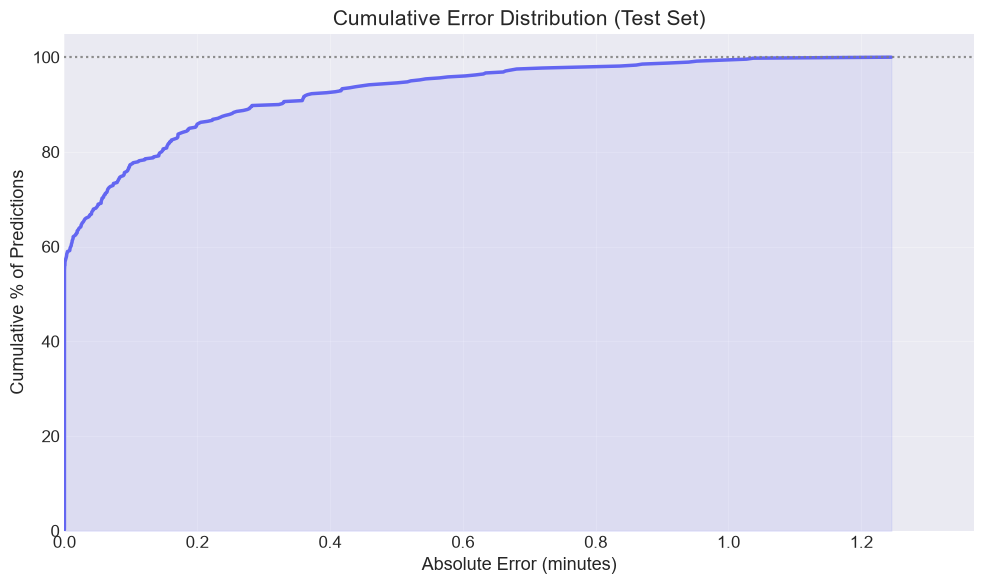

📊 Saved: cumulative_error.png


In [29]:
# What percentage of predictions fall within X minutes of the true value?
abs_errors_sorted = np.sort(np.abs(y_test - y_pred_test))
cumulative = np.arange(1, len(abs_errors_sorted) + 1) / len(abs_errors_sorted) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(abs_errors_sorted, cumulative, color=COLORS['primary'], linewidth=2.5)
ax.fill_between(abs_errors_sorted, cumulative, alpha=0.1, color=COLORS['primary'])

# Add reference lines for key thresholds
for threshold in [5, 10, 20]:
    pct = np.mean(np.abs(y_test - y_pred_test) <= threshold) * 100
    ax.axvline(x=threshold, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(y=pct, color='gray', linestyle=':', alpha=0.5)
    ax.annotate(f'{pct:.1f}% within {threshold} min',
                xy=(threshold, pct), xytext=(threshold + 2, pct - 5),
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=COLORS['dark']),
                color=COLORS['dark'])

ax.set_xlabel('Absolute Error (minutes)', fontsize=13)
ax.set_ylabel('Cumulative % of Predictions', fontsize=13)
ax.set_title('Cumulative Error Distribution (Test Set)', fontsize=15)
ax.set_xlim([0, abs_errors_sorted[-1] * 1.1])
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cumulative_error.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: cumulative_error.png")

---

## 6. Summary Dashboard

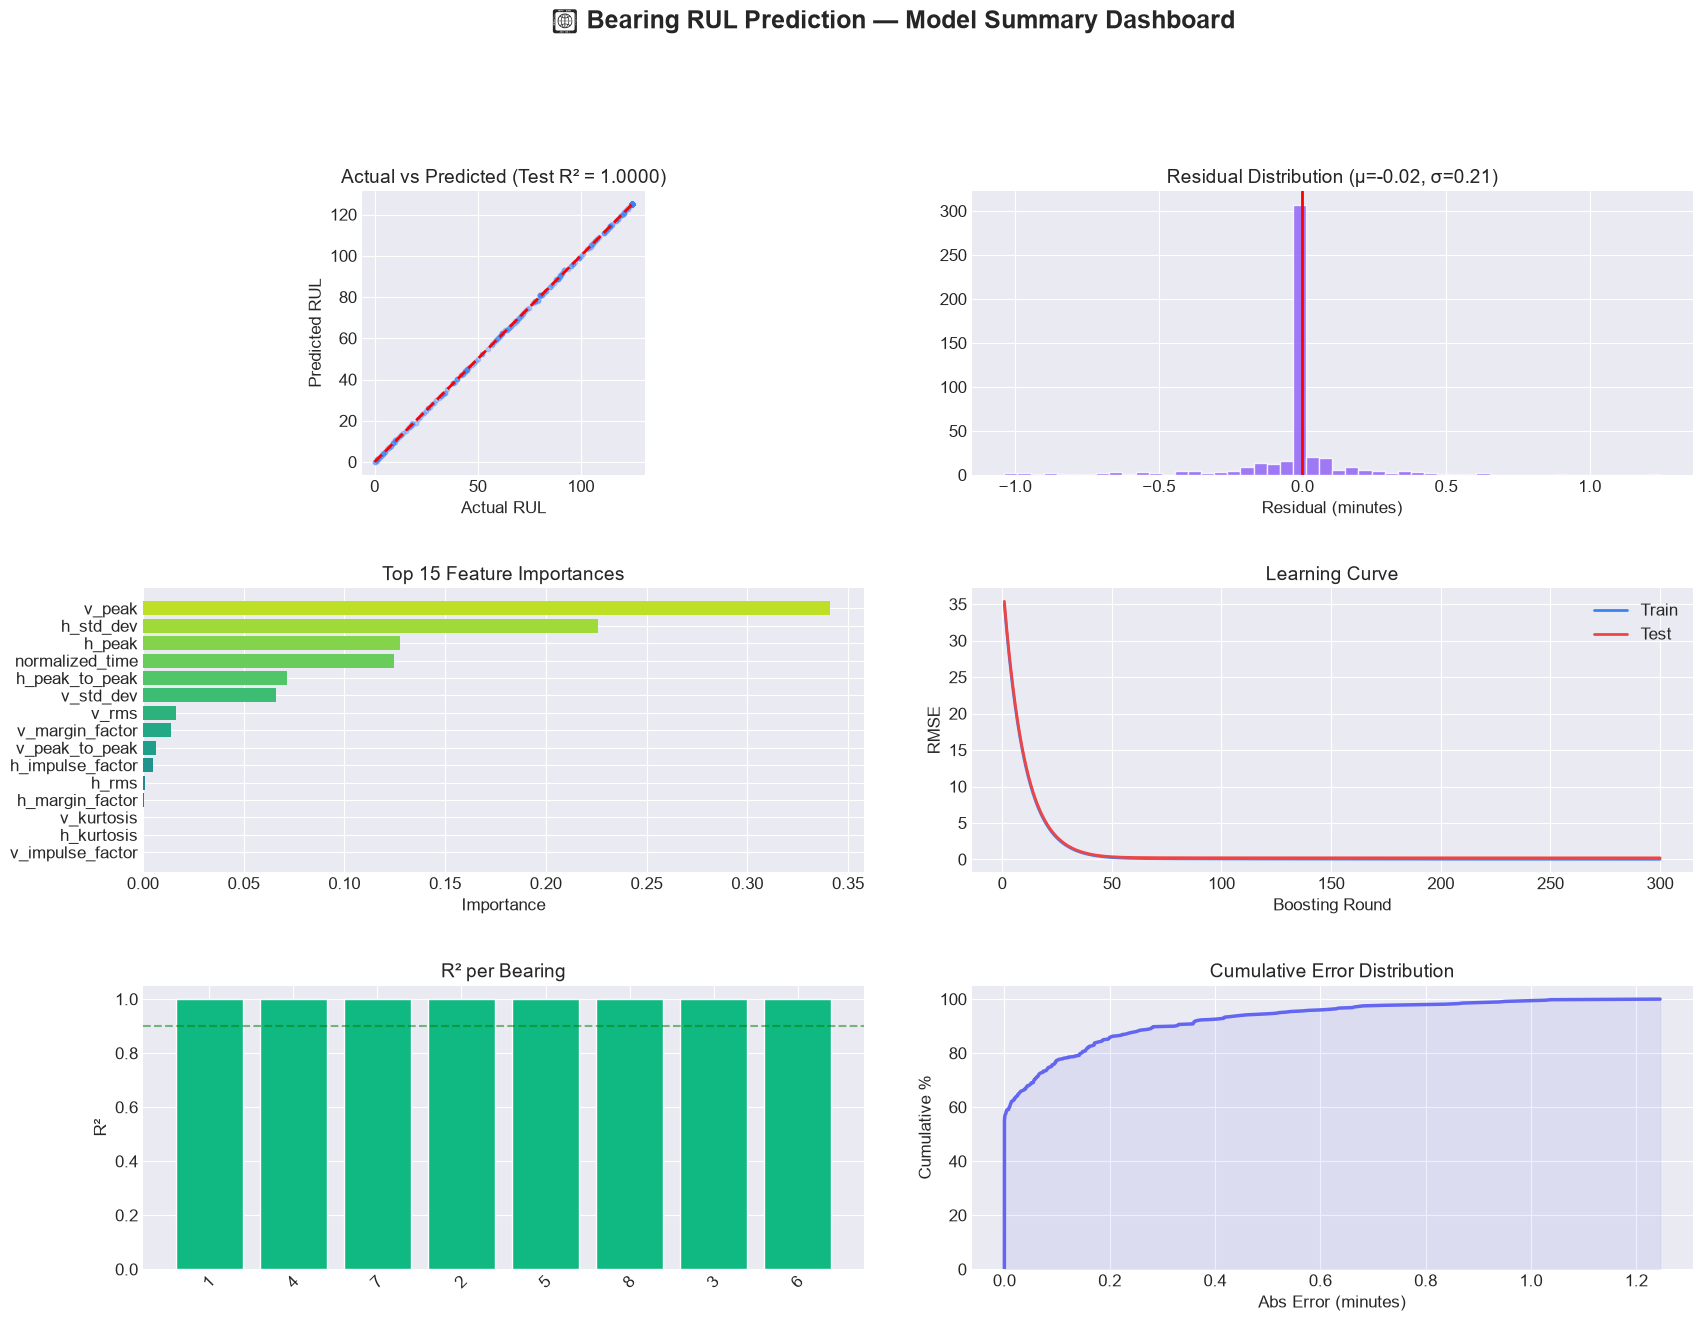

📊 Saved: summary_dashboard.png


In [30]:
# Create a comprehensive summary dashboard
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 4, hspace=0.4, wspace=0.35)

# 1. Actual vs Predicted (Test)
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.scatter(y_test, y_pred_test, alpha=0.3, s=10, color=COLORS['info'])
ax1.plot([0, y.max()], [0, y.max()], 'r--', linewidth=2)
ax1.set_xlabel('Actual RUL')
ax1.set_ylabel('Predicted RUL')
ax1.set_title(f'Actual vs Predicted (Test R² = {test_metrics["R²"]:.4f})')
ax1.set_aspect('equal', adjustable='box')

# 2. Residual histogram
ax2 = fig.add_subplot(gs[0, 2:4])
ax2.hist(residuals_test, bins=50, color=COLORS['secondary'], alpha=0.8, edgecolor='white')
ax2.axvline(x=0, color='red', linewidth=2)
ax2.set_xlabel('Residual (minutes)')
ax2.set_title(f'Residual Distribution (μ={np.mean(residuals_test):.2f}, σ={np.std(residuals_test):.2f})')

# 3. Feature importance (top 15)
ax3 = fig.add_subplot(gs[1, 0:2])
top15 = importance_df.tail(15)
ax3.barh(top15['Feature'], top15['Importance'], color=plt.cm.viridis(np.linspace(0.3, 0.9, 15)))
ax3.set_xlabel('Importance')
ax3.set_title('Top 15 Feature Importances')

# 4. Learning curve
ax4 = fig.add_subplot(gs[1, 2:4])
ax4.plot(epochs, train_rmse, label='Train', color=COLORS['info'], linewidth=2)
ax4.plot(epochs, test_rmse, label='Test', color=COLORS['danger'], linewidth=2)
ax4.set_xlabel('Boosting Round')
ax4.set_ylabel('RMSE')
ax4.set_title('Learning Curve')
ax4.legend()

# 5. Per-bearing R² scores
ax5 = fig.add_subplot(gs[2, 0:2])
bar_colors_dash = [COLORS['success'] if r >= 0.9 else COLORS['warning'] for r in bearing_df['R²'].values]
ax5.bar(range(len(bearing_df)), bearing_df['R²'].values, color=bar_colors_dash, edgecolor='white')
ax5.set_xticks(range(len(bearing_df)))
ax5.set_xticklabels([n.split('_')[-1] if 'Synthetic' in n else n[:8] for n in bearing_df.index], rotation=45)
ax5.set_ylabel('R²')
ax5.set_title('R² per Bearing')
ax5.axhline(y=0.9, color='green', linestyle='--', alpha=0.5)

# 6. Cumulative error
ax6 = fig.add_subplot(gs[2, 2:4])
ax6.plot(abs_errors_sorted, cumulative, color=COLORS['primary'], linewidth=2.5)
ax6.fill_between(abs_errors_sorted, cumulative, alpha=0.1, color=COLORS['primary'])
ax6.set_xlabel('Abs Error (minutes)')
ax6.set_ylabel('Cumulative %')
ax6.set_title('Cumulative Error Distribution')
ax6.set_ylim([0, 105])

plt.suptitle('🔧 Bearing RUL Prediction — Model Summary Dashboard', fontsize=18, y=1.01, fontweight='bold')
plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: summary_dashboard.png")

---

## 7. Final Summary

### Files Generated
| File | Description |
|------|-------------|
| `bearing_features_dataset.csv` | Full feature dataset used for training |
| `rul_distribution.png` | RUL distribution visualizations |
| `feature_degradation.png` | Feature trends over bearing lifecycle |
| `correlation_heatmap.png` | Feature correlation matrix |
| `feature_rul_correlation.png` | Feature correlations with RUL |
| `features_by_health.png` | Feature distributions by health status |
| `learning_curves.png` | XGBoost training/test RMSE over epochs |
| `actual_vs_predicted.png` | Scatter plots of actual vs predicted RUL |
| `residual_analysis.png` | Comprehensive residual analysis |
| `feature_importance.png` | XGBoost feature importance rankings |
| `per_bearing_scores.png` | R² and RMSE scores per bearing |
| `rul_timeline.png` | Predicted vs actual RUL timelines |
| `error_by_health_zone.png` | Error distributions in health zones |
| `cumulative_error.png` | Cumulative error distribution |
| `summary_dashboard.png` | Complete summary dashboard |

In [31]:
# Print final metrics summary
print("\n" + "="*60)
print("        FINAL MODEL EVALUATION SUMMARY")
print("="*60)
print(f"\n  Dataset:")
print(f"    Total samples:     {len(df)}")
print(f"    Bearings:          {df['bearing_name'].nunique()}")
print(f"    Features:          {len(feature_cols)}")
print(f"    Train/Test split:  {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"\n  Test Set Scores:")
print(f"    R² Score:          {test_metrics['R²']:.6f}")
print(f"    RMSE:              {test_metrics['RMSE (min)']:.4f} minutes")
print(f"    MAE:               {test_metrics['MAE (min)']:.4f} minutes")
print(f"    Median AE:         {test_metrics['Median AE (min)']:.4f} minutes")
print(f"    Max Error:         {test_metrics['Max Error (min)']:.4f} minutes")
print(f"\n  Train Set Scores:")
print(f"    R² Score:          {train_metrics['R²']:.6f}")
print(f"    RMSE:              {train_metrics['RMSE (min)']:.4f} minutes")
print(f"    MAE:               {train_metrics['MAE (min)']:.4f} minutes")
print(f"\n  Per-Bearing R² Range:")
print(f"    Min:               {bearing_df['R²'].min():.4f}")
print(f"    Max:               {bearing_df['R²'].max():.4f}")
print(f"    Mean:              {bearing_df['R²'].mean():.4f}")
print(f"    Std:               {bearing_df['R²'].std():.4f}")
print(f"\n  Error Percentiles (Test Set):")
abs_err = np.abs(y_test - y_pred_test)
for p in [50, 75, 90, 95, 99]:
    print(f"    {p}th percentile:    {np.percentile(abs_err, p):.2f} minutes")
print("\n" + "="*60)
print("✅ Analysis complete!")


        FINAL MODEL EVALUATION SUMMARY

  Dataset:
    Total samples:     2400
    Bearings:          8
    Features:          30
    Train/Test split:  80% / 20%

  Test Set Scores:
    R² Score:          0.999970
    RMSE:              0.2130 minutes
    MAE:               0.0918 minutes
    Median AE:         0.0002 minutes
    Max Error:         1.2452 minutes

  Train Set Scores:
    R² Score:          1.000000
    RMSE:              0.0261 minutes
    MAE:               0.0119 minutes

  Per-Bearing R² Range:
    Min:               1.0000
    Max:               1.0000
    Mean:              1.0000
    Std:               0.0000

  Error Percentiles (Test Set):
    50th percentile:    0.00 minutes
    75th percentile:    0.09 minutes
    90th percentile:    0.32 minutes
    95th percentile:    0.52 minutes
    99th percentile:    0.94 minutes

✅ Analysis complete!
